<a href="https://colab.research.google.com/github/CitlaliCruzVazquez-ui/M-todos-num-ricos-II-/blob/main/Regla_compuesta_de_Simpson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Método Numéricos: Regla Compuesta de Simpson
**Nombre:**Citlali Cruz Vazquez
**Fecha:** 05-Octubre-2026


---

## 1. Introducción y Formulación Teórica
El objetivo de esta práctica es implementar el **Algoritmo 4.1 (Regla Compuesta de Simpson)** basado en el libro de Análisis Numérico de Burden (pág. 153).
Este método busca aproximar la integral definida de una función $f(x)$ en el intervalo $[a, b]$ dividiendo el intervalo en $n$ subintervalos de igual tamaño (donde $n$ debe ser un número entero positivo **par**).

La fórmula general para la Regla Compuesta de Simpson es:

$$\int_{a}^{b} f(x) \, dx \approx \frac{h}{3} \left[ f(a) + 2 \sum_{j=1}^{(n/2)-1} f(x_{2j}) + 4 \sum_{j=1}^{n/2} f(x_{2j-1}) + f(b) \right]$$

donde $h = \frac{b - a}{n}$ y los puntos están dados por $x_i = a + i \cdot h$ para $i = 0, 1, \dots, n$.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2222036179.py, line 3)

In [ ]:
## 2. Importación de Librerías

Para realizar el cálculo numérico y graficar la función junto con las regiones de integración, utilizaremos `numpy` y `matplotlib`.

SyntaxError: invalid syntax (2693104116.py, line 3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seteamos un estilo sencillo para las gráficas
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')

In [ ]:
## 3. Definición del Algoritmo 4.1 (Burden)

Implementamos la función seguiendo fielmente la lógica de variables del libro ($XI0$, $XI1$, $XI2$, $XI$)[span_3](start_span)[span_3](end_span).

**Variables principales:**
* `a`, `b`: Extremos del intervalo[span_4](start_span)[span_4](end_span).
* `n`: Número de subintervalos (debe ser par)[span_5](start_span)[span_5](end_span).
* `XI0`: Suma de las evaluaciones de los extremos $f(a) + f(b)$[span_6](start_span)[span_6](end_span).
* `XI1`: Suma acumulada para los términos impares $f(x_{2i-1})$[span_7](start_span)[span_7](end_span).
* `XI2`: Suma acumulada para los términos pares $f(x_{2i})$[span_8](start_span)[span_8](end_span).

SyntaxError: invalid decimal literal (3060915780.py, line 9)

In [ ]:
def regla_simpson_compuesta(f, a, b, n):
    # Verificamos que n sea par según la restricción del algoritmo
    if n % 2 != 0:
        raise ValueError("El número de subintervalos 'n' debe ser un número entero par.")

    # Paso 1: Calculamos el tamaño del paso h
    h = (b - a) / n

    # Paso 2: Inicializamos las sumas acumuladas
    XI0 = f(a) + f(b)
    XI1 = 0.0  # Para la suma de los nodos impares
    XI2 = 0.0  # Para la suma de los nodos pares

    # Paso 3, 4 y 5: Ciclo para evaluar los puntos intermedios (x_1 hasta x_{n-1})
    for i in range(1, n):
        X = a + i * h  # Nodo actual x_i

        # En Python los índices son iguales que en el libro, evaluamos paridad de i:
        if i % 2 == 0:
            XI2 += f(X)  # Acumulamos en XI2 si el índice i es par
        else:
            XI1 += f(X)  # Acumulamos en XI1 si el índice i es impar

    # Paso 6: Combinamos los términos con la ponderación de la regla de Simpson
    XI = h * (XI0 + 2 * XI2 + 4 * XI1) / 3.0

    # Paso 7: Retornamos la aproximación calculada
    return XI

In [ ]:
## 4. Prueba con el Ejercicio 1 de la Tarea 1

Definimos la función del problema a evaluar junto con sus parámetros $a$, $b$ y $n$

> **Nota:** Cambia los valores de la función `f(x)`, `a`, `b` y `n` según lo que dicte exactamente tu ejercicio de la Tarea 1.

*(Ejemplo típico de la tarea: $\int_{0}^{\pi} \sin(x) \, dx$ con $n = 6$)*

SyntaxError: invalid syntax (2133424100.py, line 3)

In [ ]:
# --- Definición de la función del Ejercicio 1 ---
# MODIFICA AQUÍ si tu Ejercicio 1 tiene otra función:
def f(x):
    return np.sin(x)

# Parámetros del problema
a = 0.0           # Límite inferior
b = np.pi         # Límite superior
n = 6             # Número de divisiones (debe ser par)

# Ejecutamos el método
resultado = regla_simpson_compuesta(f, a, b, n)

# Impresión del resultado resaltado
print("="*45)
print(f" RESULTADO FINAL DE LA INTEGRACIÓN")
print("="*45)
print(f" Aproximación de Simpson (n={n}): XI = {resultado:.6f}")
print("="*45)

 RESULTADO FINAL DE LA INTEGRACIÓN
 Aproximación de Simpson (n=6): XI = 2.000863


In [ ]:
## 5. Visualización Gráfica

Graficamos la función $f(x)$ y coloreamos el área bajo la curva aproximada para ver visualmente la zona que estamos integrando.

SyntaxError: invalid syntax (1686588822.py, line 3)

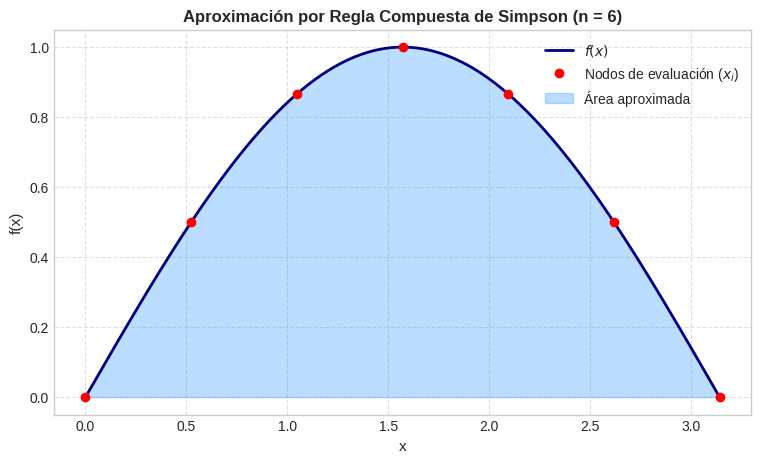

In [ ]:
# Generamos puntos para una curva suave
x_curve = np.linspace(a, b, 200)
y_curve = f(x_curve)

# Puntos discretos de los subintervalos del método
x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

plt.figure(figsize=(9, 5))

# Trazamos la función original
plt.plot(x_curve, y_curve, label=r'$f(x)$', color='navy', linewidth=2)

# Graficamos los nodos evaluados por el algoritmo
plt.plot(x_nodes, y_nodes, 'ro', label='Nodos de evaluación ($x_i$)')

# Rellenamos el área bajo la curva
plt.fill_between(x_curve, y_curve, alpha=0.3, color='dodgerblue', label='Área aproximada')

# Configuración de ejes y títulos
plt.title(f'Aproximación por Regla Compuesta de Simpson (n = {n})', fontsize=12, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('f(x)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()